# `kNNpy.kNN_3D.TracerAuto3D` Tutorial: Clustering in a 3D simulation box using 3D $k$-nearest neighbour distributions

**Author**: Anargha Mondal\
**Date**: 27 June 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `kNNpy.kNN_3D.TracerAuto3D` module to compute the 3D $k$NN distributions in a simulation box for given data and interpret the results. The basic functionalities of the module are illustrated using realistic cosmological datasets. A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/kNN_3D.TracerAuto3D.html) and source code for the module is available on the `kNNpy` [website](https://kitnenikatnivasi.github.io/).

<!--TABLE OF CONTENTS-->
# Contents:
- [Imports and Setup](#Imports-and-Setup)
- [Auto clustering of discrete tracers](#Auto-clustering-of-discrete-tracers)
    - [Visualise the data](#Let's-vizualize-how-tracers-are-distributed-in-the-sky)
    - [Compute the relevant spatial scales.](#The-clustered-nature-of-the-haloes-can-clearly-be-seen-the-sky-map,-and-it-is-our-task-to-quantify-the-extent-of-this-clustering.-The-first-step-is-to-compute-the-relevant-spatial-scales-of-interest-at-which-the-$k$NN-distributions-can-be-computed.)
    - [Construct the query points from](#The-next-step-is-to-construct-the-query-points-from-which-the-nearest-neighbnour-distances-are-to-be-computed:)
    - [Compute the $k$NN-CDFs](#Now,-we-are-ready-to-compute-the-$k$NN-CDFs-and-measure-the-angular-auto-clustering-of-the-Quijote-galaxy-scale-dark-matter-haloes!-Let's-do-that-using-the-`TracerAuto2DA()`-method:)
    - [Interpretation of results](#let's-visualise-the-results,-comparing-the-evaluated-CDFs-against-the-theoretical-expectation-for-unclustered-data:)

# Imports and Setup

#### Let's start by importing the required Python libraries. These should already be present in the `kNNpy_env` virtual environment created during the [installation](https://kitnenikatnivasi.github.io/install.html), so you should be able to import them without any issues.

In [1]:
#Importing external libraries

import numpy as np

from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors

import copy

import os
import sys

import warnings

#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('../'))           # '../' is needed because the parent directory is one directories upstream of the tutorials directory
if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf                 #some helper functions
from kNNpy import kNN_3D as k3D                            #the main module
from kNNpy.Data import Datasets                         #helpful for retreiving example datasets

In [2]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 18})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']

# Auto clustering of discrete tracers

#### First, we demonstrate how to use `kNNpy` to quantify the spatial clustering of discrete data points distributed in the sky.

#### Let's illustrate this using a downsampling of dark matter particles from the publicly available [Quijote simulations](https://quijote-simulations.readthedocs.io/en/latest/). 

In [33]:
pos_array_1 = Datasets.Sample3DTracersFromQuijoteBox('particles', 1, 100000)
randoms = Datasets.Sample3DPoissonTracers(1, 100000)

Averaging across the independent realisations of particle draws to reduce sampling variance due to downsampling

In [34]:
TracerPos = np.mean(pos_array_1, axis=0)
print(TracerPos.shape)


(100000, 3)


#### To estimate the relevant spatial scales, we can use the expected $k$NN-CDFs for unclustered tracers with given number density, which can be defined analytically. Let's do that for the first, second and fourth nearst neighbours using the in-build `PoissonUniformCDFs_3D()` helper function:

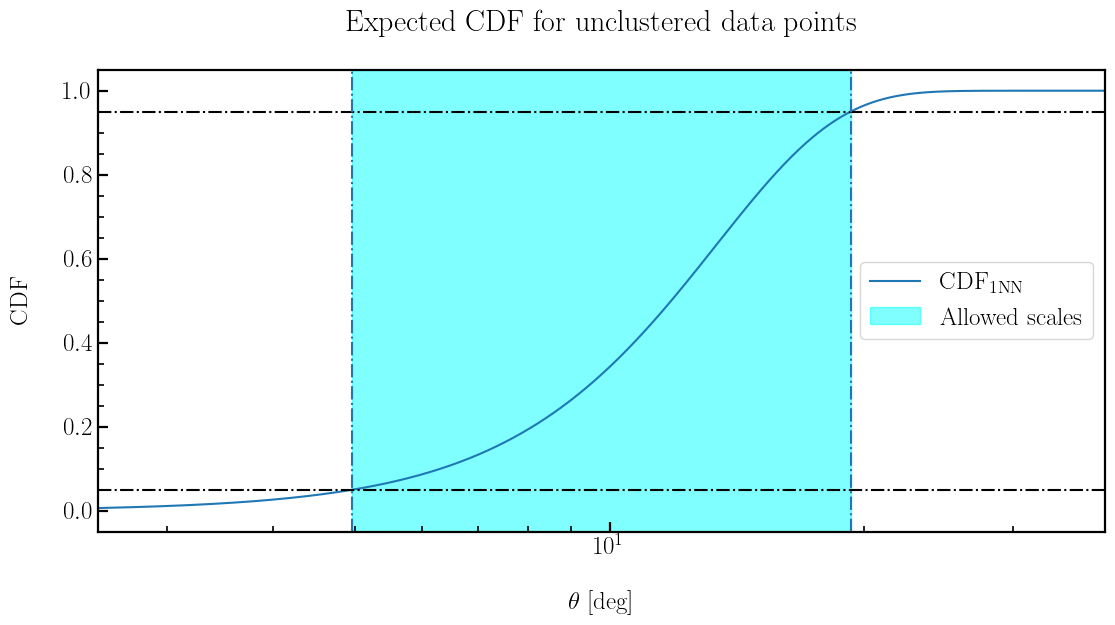

Relevant angular distance scales (deg):

	1NN:	 4.97 19.28
	2NN:	 9.47 22.46
	4NN:	 14.84 26.46


In [5]:
#Defining which neighbours to use
k_List = [1, 2, 4]

#Computing the analytical value of the kNN-CDFs for unclustered data on a wide range of angular scales

bins = np.zeros((len(k_List), 10000))
for i, k in enumerate(k_List):
    bins[i] = np.geomspace(0.5, 100, 10000)

Theoretical_Uniform_CDFs_test = []
for i, k in enumerate(k_List):
    Theoretical_Uniform_CDFs_test.append(hf.PoissonUniformCDFs_3D((4/3)*np.pi*(bins[i]**3), 10**(-4), k))

#Selecting 10 log-spaced bins where the kNN-CDFs are expected to be between 0.05 and 0.95

low_bin = np.zeros(len(k_List)).astype(int)
high_bin = np.zeros(len(k_List)).astype(int)

for i, k in enumerate(k_List):
    low_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.05)
    high_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.95)

#Let's plot the expected $k$NN-CDFs for the unclustered data
plt.figure(figsize=(13,6))
# for i, k in enumerate(k_List):
#     plt.plot(np.rad2deg(bins[i]), Theoretical_Uniform_CDFs_test[i], label='CDF$_{{\\rm {}NN}}$'.format(k))
i=0
k=1
plt.plot(bins[i], Theoretical_Uniform_CDFs_test[i], label='CDF$_{{\\rm {}NN}}$'.format(k))
plt.axhline(0.05, ls='-.', c='k')
plt.axhline(0.95, ls='-.', c='k')
plt.axvline(bins[i][low_bin[i]], ls='-.', c=DefaultColorCycle[i])
plt.axvline(bins[i][high_bin[i]], ls='-.', c=DefaultColorCycle[i])
plt.axvspan(bins[i][low_bin[i]], bins[i][high_bin[i]], alpha=0.5, color=BrightColors[i], label=f'Allowed scales')
plt.xlim([bins[0][low_bin[0]]*0.5, bins[0][high_bin[0]]*2])
plt.title('Expected CDF for unclustered data points\n')
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('CDF\n')
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()
plt.close()

#Print out the scales
print('Relevant angular distance scales (deg):\n')
for i, k in enumerate(k_List):
    print(f'\t{k}NN:\t', '{:.2f}'.format(bins[i][low_bin[i]]), '{:.2f}'.format(bins[i][high_bin[i]]))
# Uncomment lines below to print out the exact scales sampled
# for i, k in enumerate(k_List):
#     print(f'\nAngular distance bins for {k}NN-CDF: \n\n', np.rad2deg(sel_bins[i]))
#     print(f'\nNumber of bins for {k}NN-CDF: ', len(sel_bins[i]))

In [6]:
box_size=1000 # Mpc/h

r_min_1NN, r_max_1NN = 4.97, 19.28 #Mpc/h
r_min_2NN, r_max_2NN = 9.47, 22.46 #Mpc/h
r_min_4NN, r_max_4NN = 14.04, 26.46 #Mpc/h

bin1NN = np.geomspace(r_min_1NN, r_max_1NN, 30)
bin2NN = np.geomspace(r_min_2NN, r_max_2NN, 30)
bin4NN = np.geomspace(r_min_4NN, r_max_4NN, 30)

Sampling the 3D box with query points to accurately measure the CDFs. For this, the number of query points should always be greater than the number of data points. 

In [7]:
QueryPos = hf.create_query_3D('random', 256, box_size)

Calculating the kNN CDFs for k=1,2,4

In [35]:
kNN_results = k3D.TracerAuto3D(box_size, [1,2,4], [bin1NN, bin2NN, bin4NN], QueryPos, TracerPos)

In [28]:
random_results = k3D.TracerAuto3D(box_size, [1,2,4], [bin1NN, bin2NN, bin4NN], QueryPos, randoms[0])

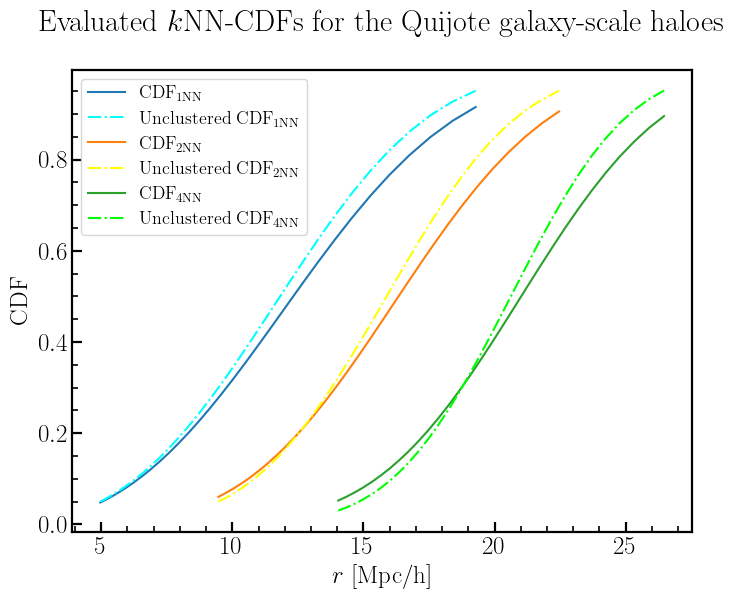

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
bin = [bin1NN, bin2NN, bin4NN]
for i, k in enumerate(k_List):
    ax.plot(bin[i], kNN_results[0][i], label='CDF$_{{\\rm {}NN}}$'.format(k))
    ax.plot(bin[i], random_results[0][i], label='Unclustered CDF$_{{\\rm {}NN}}$'.format(k), c=BrightColors[i], ls='-.')
    ax.set_xlabel(r'$r$ [Mpc/h]')
    ax.set_ylabel('CDF')
ax.legend(fontsize=13)
ax.set_title('Evaluated $k$NN-CDFs for the Quijote galaxy-scale haloes\n')
plt.subplots_adjust(wspace=0.3)
plt.show()
plt.close()